In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"на: {device}")

class AlphabetDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32) / 255.0
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

data = pd.read_csv('A_Z Handwritten Data.csv').values # Вкажи свій шлях

X = data[:, 1:]
y = data[:, 0]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_dataset = AlphabetDataset(X_train, y_train)
test_dataset = AlphabetDataset(X_test, y_test)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Тренувальних: {len(train_dataset)}, Тестових: {len(test_dataset)}")

на: cpu
Тренувальних: 297960, Тестових: 74490


In [4]:
class LinearAlphabetModel(nn.Module):
    def __init__(self, input_size=784, num_classes=26):
        super(LinearAlphabetModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.network(x)
model = LinearAlphabetModel().to(device)
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

LinearAlphabetModel(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=26, bias=True)
  )
)


In [5]:
epochs = 10
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()       
        outputs = model(inputs)   
        loss = criterion(outputs, labels) 
        loss.backward()             
        optimizer.step()             
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_loss = running_loss / total
    train_acc = correct / total
    
    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    test_loss = test_loss / total
    test_acc = correct / total
    
    # Зберігаємо метрики
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Epoch [1/10] | Train Loss: 0.2522, Train Acc: 0.9294 | Test Loss: 0.1107, Test Acc: 0.9685
Epoch [2/10] | Train Loss: 0.0890, Train Acc: 0.9742 | Test Loss: 0.0783, Test Acc: 0.9775
Epoch [3/10] | Train Loss: 0.0609, Train Acc: 0.9816 | Test Loss: 0.0635, Test Acc: 0.9815
Epoch [4/10] | Train Loss: 0.0438, Train Acc: 0.9864 | Test Loss: 0.0616, Test Acc: 0.9820
Epoch [5/10] | Train Loss: 0.0338, Train Acc: 0.9893 | Test Loss: 0.0518, Test Acc: 0.9852
Epoch [6/10] | Train Loss: 0.0272, Train Acc: 0.9910 | Test Loss: 0.0496, Test Acc: 0.9863
Epoch [7/10] | Train Loss: 0.0228, Train Acc: 0.9924 | Test Loss: 0.0489, Test Acc: 0.9870
Epoch [8/10] | Train Loss: 0.0199, Train Acc: 0.9934 | Test Loss: 0.0489, Test Acc: 0.9872
Epoch [9/10] | Train Loss: 0.0191, Train Acc: 0.9937 | Test Loss: 0.0477, Test Acc: 0.9887
Epoch [10/10] | Train Loss: 0.0156, Train Acc: 0.9948 | Test Loss: 0.0506, Test Acc: 0.9891


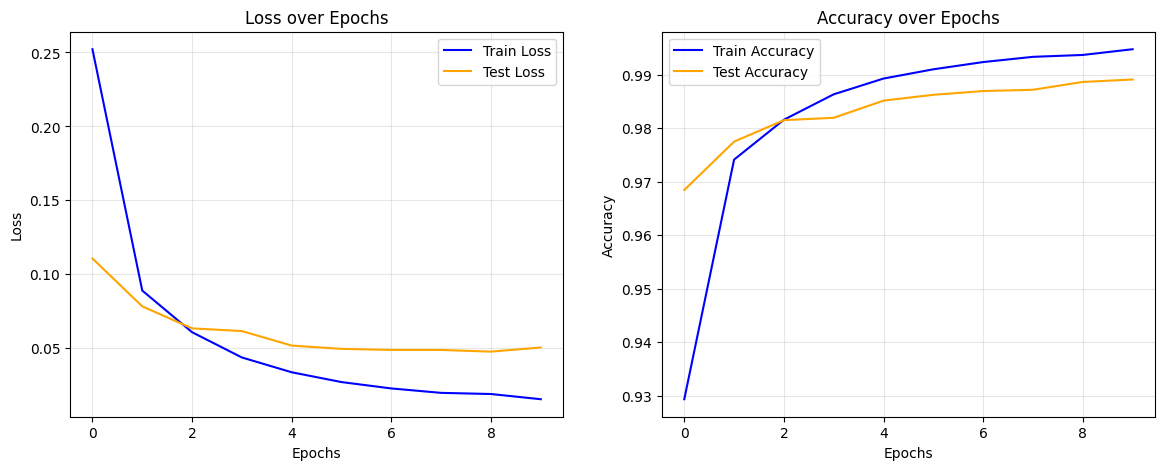

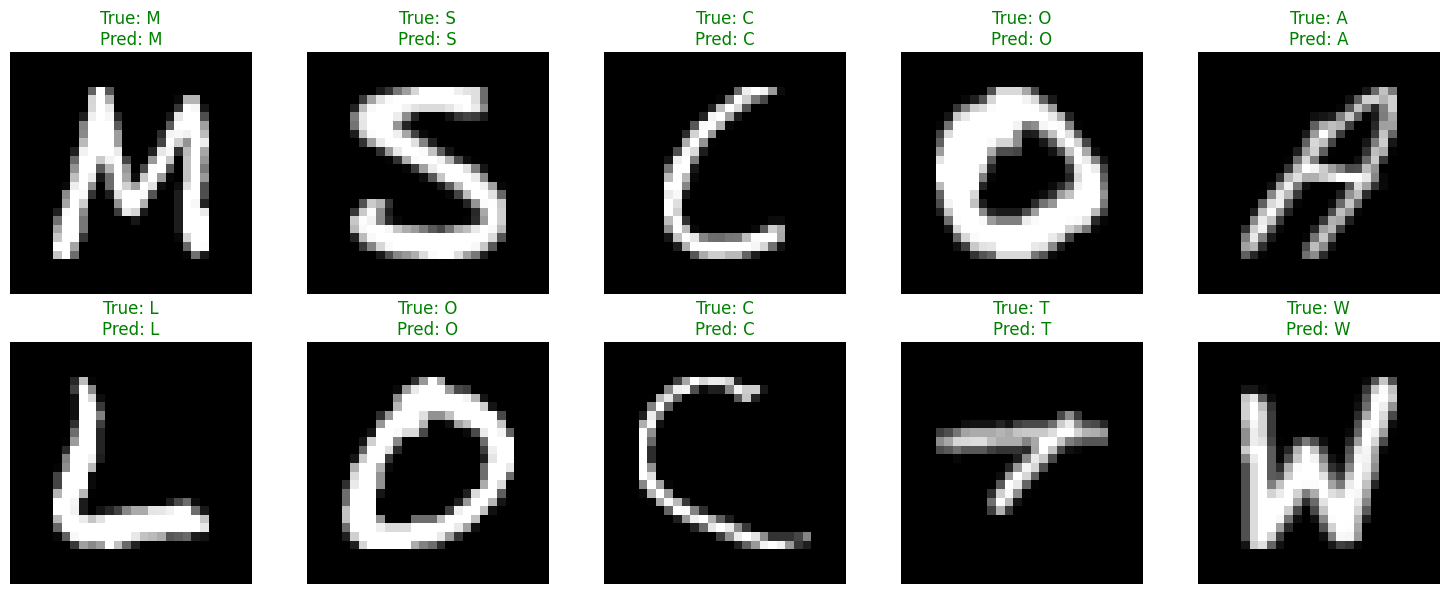

In [6]:
# Loss+Accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.plot(history['train_loss'], label='Train Loss', color='blue')
ax1.plot(history['test_loss'], label='Test Loss', color='orange')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train Accuracy', color='blue')
ax2.plot(history['test_acc'], label='Test Accuracy', color='orange')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

model.eval()
alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

# Беремо один випадковий батч з тестового набору
dataiter = iter(test_loader)
images, labels = next(dataiter)

images_gpu = images[:10].to(device)
with torch.no_grad():
    outputs = model(images_gpu)
    _, preds = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    img = images[i].numpy().reshape(28, 28)
    true_label = alphabet[labels[i].item()]
    pred_label = alphabet[preds[i].item()]
    
    axes[i].imshow(img, cmap='gray')
    #вгадали - зелений ,помилились - червоний
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()